In [5]:
import math

import matplotlib.pyplot as plt
import numpy as np

import src.util as util

We basically need to implement the equations we have derivated in the theoretical part

In [6]:
def initial_state():
    """Return the initial state for the perceptron.

    This function computes and then returns the initial state of the perceptron.
    Feel free to use any data type (dicts, lists, tuples, or custom classes) to
    contain the state of the perceptron.

    Returns:
    A list of tuples where the first element is the coefficient beta and the
    second element is the x for this coefficient.

    """

    return []



def predict(state, kernel, x_i):
    """Peform a prediction on a given instance x_i given the current state
    and the kernel.

    Args:
        state: The state returned from initial_state()
        kernel: A binary function that takes two vectors as input and returns
            the result of a kernel
        x_i: A vector containing the features for a single instance

    Returns:
        Returns the prediction (i.e 0 or 1)
    """
    sum_ = 0
    for beta, x in state:
        sum_ += beta * kernel(x, x_i)
    
    return sign(sum_)



def update_state(state, kernel, learning_rate, x_i, y_i):
    """Updates the state of the perceptron.

    Args:
        state: The state returned from initial_state()
        kernel: A binary function that takes two vectors as input and returns the result of a kernel
        learning_rate: The learning rate for the update
        x_i: A vector containing the features for a single instance
        y_i: A 0 or 1 indicating the label for a single instance
    """
    beta_new = learning_rate * (y_i - predict(state, kernel, x_i))
    state.append((beta_new, x_i))

    return state


def sign(a):
    """Gets the sign of a scalar input."""
    if a >= 0:
        return 1
    else:
        return 0


def dot_kernel(a, b):
    """An implementation of a dot product kernel.

    Args:
        a: A vector
        b: A vector
    """
    return np.dot(a, b)


def rbf_kernel(a, b, sigma=1):
    """An implementation of the radial basis function kernel.

    Args:
        a: A vector
        b: A vector
        sigma: The radius of the kernel
    """
    distance = (a - b).dot(a - b)
    scaled_distance = -distance / (2 * (sigma) ** 2)
    return math.exp(scaled_distance)


def train_perceptron(kernel_name, kernel, learning_rate):
    """Train a perceptron with the given kernel.

    This function trains a perceptron with a given kernel and then
    uses that perceptron to make predictions.
    The output predictions are saved to src/output/p05_{kernel_name}_predictions.txt.
    The output plots are saved to src/output_{kernel_name}_output.pdf.

    Args:
        kernel_name: The name of the kernel.
        kernel: The kernel function.
        learning_rate: The learning rate for training.
    """
    train_x, train_y = util.load_csv(r"C:\cs229-journey\cs229-journey\problem_sets\PS2\data\ds5_train.csv")

    state = initial_state()

    for x_i, y_i in zip(train_x, train_y):
        update_state(state, kernel, learning_rate, x_i, y_i)

    test_x, test_y = util.load_csv(r"C:\cs229-journey\cs229-journey\problem_sets\PS2\data\ds5_test.csv")

    plt.figure(figsize=(12, 8))
    plt.grid()
    plt.title(f"Decision boundaraty. Kernel: {kernel_name}")
    util.plot_contour(lambda a: predict(state, kernel, a))
    util.plot_points(test_x, test_y)

    predict_y = [predict(state, kernel, test_x[i, :]) for i in range(test_y.shape[0])]

    return f"Test accuracy for kernel {kernel_name}: {np.mean(test_y == predict_y):.2%}"



'Test accuracy for kernel dot: 52.50%'

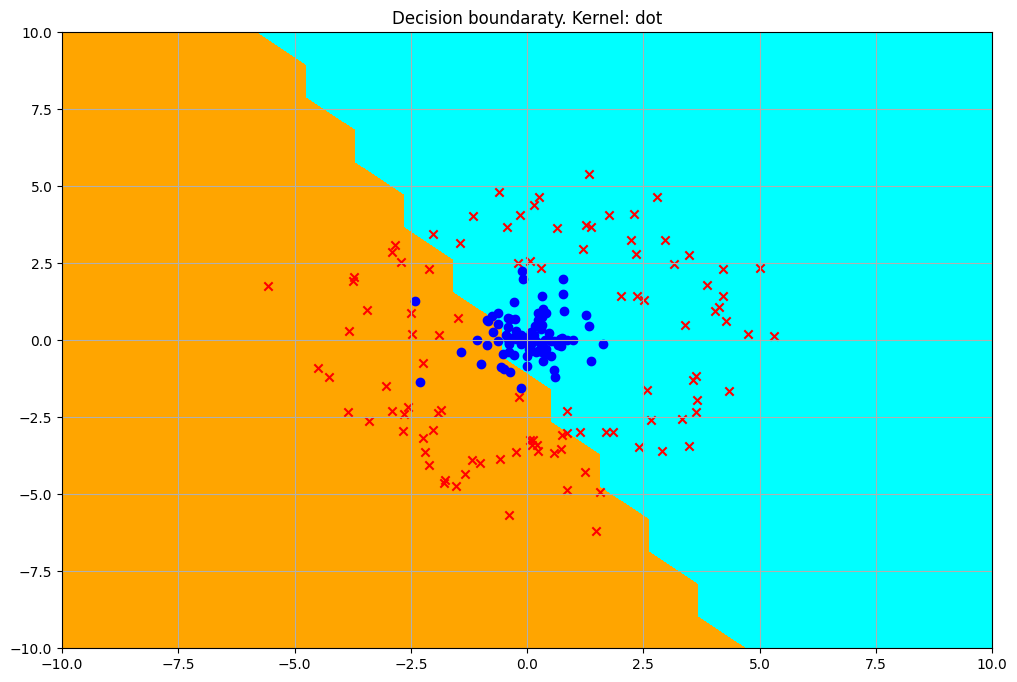

In [7]:
#We train the SVM with the dot kernel
train_perceptron("dot", dot_kernel, 0.5)


'Test accuracy for kernel rbf: 92.00%'

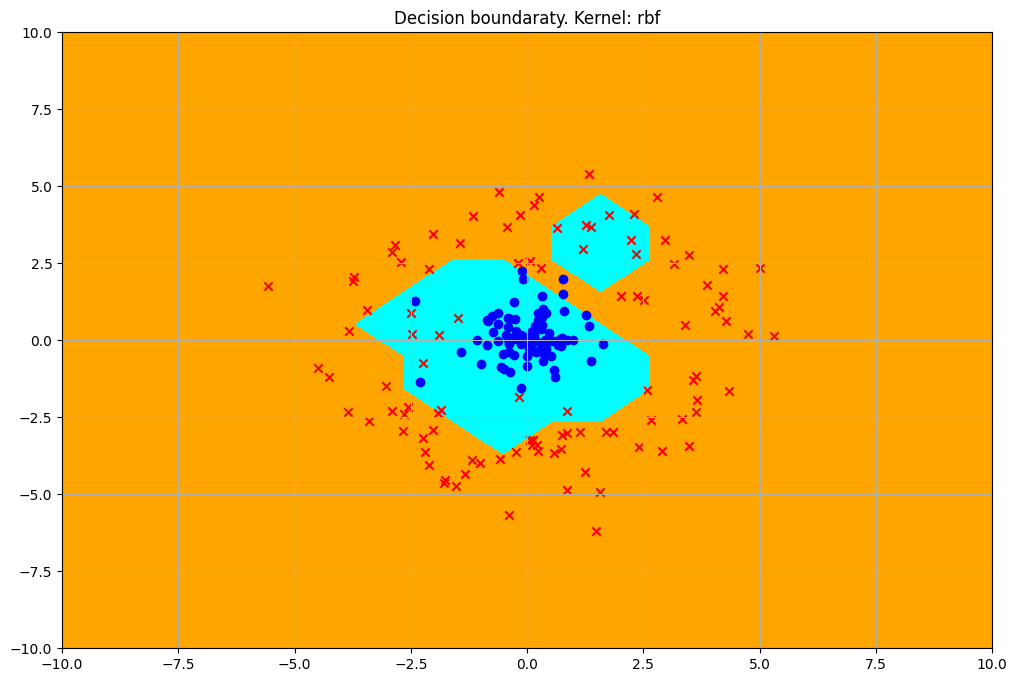

In [8]:
#We train the SVM with the rbf kernel
train_perceptron("rbf", rbf_kernel, 0.5)

For the product kernel, there is no feature mapping for the input attributes. In other words, the model is still linear
after applying the product kernel. As a consequence, it performs badly on the data that are not linearly separable.

With equations:
$$
K(x, y) = \phi^T(x)\phi(y) = x^T \cdot y
$$

as we see the feature space is not changed.